# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
import time

# Local importations
from moments.bloch import (compute_gell_mann_basis, compute_tensor_basis, compute_subset_index_map,
                           compute_bipartite_region_upper, compute_bipartite_region_lower)
from moments.initialization import compute_initial_param_repeat

# Saving
from moments.saving import get_experiment_paths

data_dir, _ = get_experiment_paths(__vsc_ipynb_file__)

# Hilbert space definition

States belong to the Hilbert space $\mathcal H = \mathcal H_1 \otimes \mathcal H_2$, where $\dim \mathcal H_1 = \dim \mathcal H_2 = 3$. As a consequence, $d = \dim \mathcal H = 3^2 = 9$.
We denote the Gell-Mann bases of the local Hilbert spaces by $\{\mu^{(n)}_i\}_{i = 0}^8$. The elements of the basis satisfy:
- $\mu^{(n)}_i = \mathbb I_3$,
- $\mu^{(n)}_i = (\mu^{(n)}_i)^\dagger$,
- $\operatorname{tr} (\mu^{(n)}_i) = \delta_{0i}$,
- $\operatorname{tr} (\mu^{(n)}_i \mu^{(n)}_j) = d_n \delta_{ij}$.

Then, the local density matrices can be written as:

$$
\rho^{(n)} = \frac1{3} \left(\mathbb I_3 + \sum_{i = 0}^{8} r^{(n)}_i \mu^{(n)}_i\right) \, ,
$$

and the global density matrix as

$$
\rho = \frac1{9} \left(\mathbb I_9 + \sum_{i_1 = 0}^{8} r^{(1)}_i \mu^{(1)}_i \otimes \mathbb I_3 + \sum_{j = 0}^{8} r^{(2)}_j \mathbb I_3 \otimes \mu^{(1)}_j + \sum_{i, j = 0}^{8} r^{(1)}_i r^{(2)}_j \mu^{(1)}_i \otimes \mu^{(1)}_j \right) \, .
$$

By their purities, the bloch norms satisfy:

$$
||r_1||^2, ||r_2||^2 \le 2 \, ; \quad ||r_{12}||^2 \le 8 \implies \, x, y \le \sqrt2 \, ; \quad z \le 2 \sqrt2 \, .
$$

Where we have defined $x := ||r_1||$, $y := ||r_2||$, $z := ||r_{12}||$.

In general, the 3D region explored consits of a subset of $\mathbb R^3$ that satisfy the constraints:

- $x, y \in [0, \sqrt2]$, $z \in [0, 2\sqrt2]$,
- $z \ge \sqrt2 (x + y) - 2$,
- $z^2 \le 8 + 2 (x^2 + y^2) - 6xy - 3 \sqrt6 |x - y|$.

In [2]:
dn, N = 3, 2
d = dn ** N

basis = compute_gell_mann_basis(dn)
local_bases = [basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

# Symetric plane

In the intersection of the region and the plane $x=y$, the inequalities become:

- $x, y \in [0, \sqrt2]$, $z \in [0, 2\sqrt2]$,
- $z \ge 2 (\sqrt2 x - 1)$,
- $z \le \sqrt{8 - 2 x^2}$.

We can call $t$ the distance to the $z$-axis from the points in the $x=y$ plane. Thus, change the coordinates to a 2D representation where we use the intersection between the $x=y$ and $z=0$ planes as first coordinate, and $z$ as the second coordinate. Then, we would have $t = \sqrt{x^2 + y^2} = \sqrt2 x$ or $x = y = t/\sqrt2$, which transforms the inequalities as:

- $t \in [0, 2]$, $z \in [0, 2\sqrt2]$,
- $z \ge 2(t - 1)$,
- $z^2 \le 8 - t^2$.

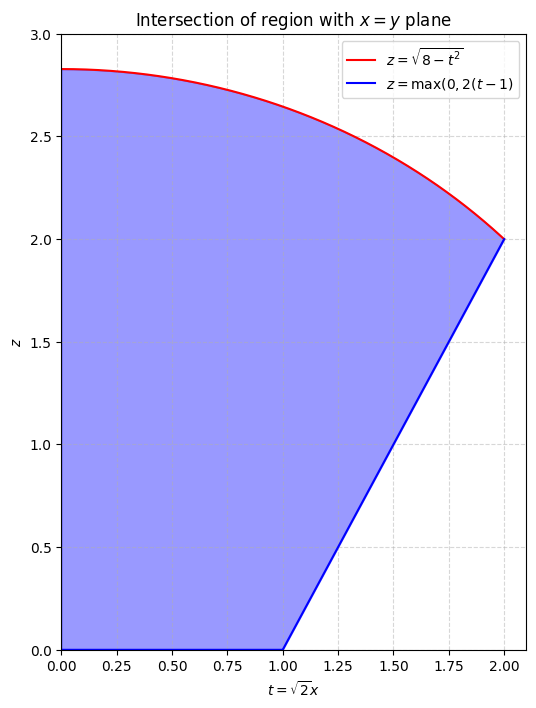

In [3]:
t = np.linspace(0, 2, 1000)
x = t / np.sqrt(2)

z_upper = compute_bipartite_region_upper(dn, x, x)
z_lower = compute_bipartite_region_lower([dn, dn], x, x)

fig, ax = plt.subplots(figsize=(6, 8))

ax.fill_between(t, z_upper, z_lower, alpha=0.4, color='blue')

ax.plot(t, z_upper, 'red', label=r"$z = \sqrt{8 - t^2}$")
ax.plot(t, z_lower, 'blue', label=r"$z = \max(0, 2 (t - 1)$")

ax.set(xlabel = r'$t = \sqrt{2} x$', ylabel = r'$z$', title = 'Intersection of region with $x=y$ plane',
       xlim = (0, 2.1), ylim = (0, 3))
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()

## Moment space discretization

In [4]:
D = 200
Dt, Dz = D + 1, int(np.sqrt(2) * D + 1)

t = np.linspace(0, 2, Dt)
x = t / np.sqrt(2)
z = np.linspace(0, 2*np.sqrt(2), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')
indices = np.ndindex(X.shape)
total_points = np.prod(X.shape)
print(f"Number of points: {total_points}")

Number of points: 56883


## Space exploration

In [5]:
times, success = [], []
bloch_distance = np.empty_like(X, dtype=float)

for counter, (idx, jdx) in enumerate(indices, 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(x_val), (1, 2): float(z_val)}

    param_res = compute_initial_param_repeat(d, tensor_basis, subset_index_map, Rt)
    
    bloch_distance[idx, jdx] = sum(list(param_res.checks["moments_distance"].values()))
    success.append(param_res.optimizer_info["success"])

    tf = time.time()

    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

np.save(data_dir / "sym_bloch_distance.npy", bloch_distance)


Progress: 100.00% (56883/56883) | Time for this point: 0.007 s

Done!
Successful optimizations: 56883/56883 | Percentage: 100.00 %
Total time: 6.84 min | Average time per point: 0.007 s


# $xz$-plane

In the intersection of the region and the plane $y=0$, the inequalities become:

- $x \in [0, \sqrt2]$, $y = 0$, $z \in [0, 2\sqrt2]$,
- $z \ge \sqrt2 x - 2$,
- $z^2 \le 8 - 3 \sqrt6 x + 2 x^2$.

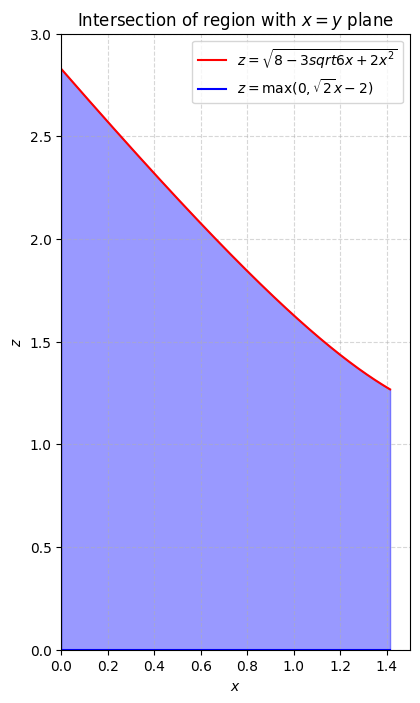

In [6]:
x = np.linspace(0, np.sqrt(2), 1000)

z_upper = compute_bipartite_region_upper(dn, x, 0)
z_lower = compute_bipartite_region_lower([dn, dn], x, 0)

fig, ax = plt.subplots(figsize=(4.5, 8))

ax.fill_between(x, z_upper, z_lower, alpha=0.4, color='blue')

ax.plot(x, z_upper, 'red', label=r"$z = \sqrt{8 - 3sqrt{6}x + 2x^2}$")
ax.plot(x, z_lower, 'blue', label=r"$z = \max(0, \sqrt{2} x - 2)$")

ax.set(xlabel = r'$x$', ylabel = r'$z$', title = 'Intersection of region with $x=y$ plane',
       xlim = (0, 1.5), ylim = (0, 3))
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()

## Moment space discretization

In [7]:
D = 200
Dx, Dz = D + 1, 2 * D + 1

x = np.linspace(0, np.sqrt(2), Dx)
z = np.linspace(0, 2*np.sqrt(2), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

indices = np.ndindex(X.shape)
total_points = np.prod(X.shape)
print(f"Number of points: {total_points}")

Number of points: 80601


## Space exploration

In [8]:
times, success = [], []
bloch_distance = np.empty_like(X, dtype=float)

for counter, (idx, jdx) in enumerate(indices, 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): 0.0, (1, 2): float(z_val)}

    param_res = compute_initial_param_repeat(d, tensor_basis, subset_index_map, Rt)
    
    bloch_distance[idx, jdx] = sum(list(param_res.checks["moments_distance"].values()))
    success.append(param_res.optimizer_info["success"])

    tf = time.time()

    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

np.save(data_dir / "xz_bloch_distance.npy", bloch_distance)

Progress: 100.00% (80601/80601) | Time for this point: 0.009 s

Done!
Successful optimizations: 80601/80601 | Percentage: 100.00 %
Total time: 10.64 min | Average time per point: 0.008 s
